# RNN_for_time_series in PyTorch (AI4PH Course)

In [3]:
# Importa las distintas librerias con sus nombres
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def generate_time_series(batch_size, n_steps):
    ''' Funcion que genera una serie temporal. 
    Las frecuencias y offsets son arrays de numeros aleatorios de tamaño (batch size, 1). El tiempo es un linspace hasta 1 en el numero de pasos determinados en el input. '''
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)
    return series[..., np.newaxis].astype(np.float32) # añade la serie como un nuevo eje  

'''
Acaba generando un array de dimensiones [batch size, n steps] con batch size series temporles de tamaño n steps
Los datos son tipo float 
'''


'\nAcaba generando un array de dimensiones [batch size, n steps] con batch size series temporles de tamaño n steps\nLos datos son tipo float \n'

In [5]:
'''
Separa los datos en train, validation y test. Se podria mejorar restando la media y escalando con la desviacion tipica
'''

np.random.seed(42)
n_steps = 50
series = generate_time_series(10000, n_steps + 1)

X_train = torch.tensor(series[:7000, :n_steps])
y_train = torch.tensor(series[:7000, -1])
X_valid = torch.tensor(series[7000:9000, :n_steps])
y_valid = torch.tensor(series[7000:9000, -1])
X_test  = torch.tensor(series[9000:, :n_steps])
y_test  = torch.tensor(series[9000:, -1])

In [ ]:
'''
Crea la clase con la red neuronal simple.
Se define self.rnn como una RNN de torch.nn y se define la funcion para hacer una pasada hacia adelante.
Se creea un modelo usando la clase, se define el criterio de perdida como mean square error y se usa el optimizador 
con Adam para entrenar los parametros de modelo con un learning rate 1e-3
'''

class SimpleRNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(1, 1, batch_first=True)

    def forward(self, x):
        _, h = self.rnn(x)
        return h.squeeze(0)

model = SimpleRNNModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [7]:
'''
Se define y ejecuta la funcion que lleva a cabo el entrenamiento y valdacion. Admite el numero de epocas como parametro y sino usa uno predefinido.
Pone el modelo en  modo entrenamiento y define como 0 los gradientes. Calcula las predicciones del modelo y calculas las perdidas en base al criterio usado.
Lleva  a cabo la backpropagation y da cambia los pesos con el optimizador. 
Sin acumular los gradientes calcula las perdidas en el validation set y muestra las epocas perdidas y perdidas de validacion.
Repite el proceso hasta consumir las epocas indicadas.
'''

def train(model, X_train, y_train, X_valid, y_valid, epochs=20):
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            model.eval()
            val_loss = criterion(model(X_valid), y_valid)

        print(f"Epoch {epoch+1}, loss={loss.item():.5f}, val={val_loss.item():.5f}")

train(model, X_train, y_train, X_valid, y_valid)

Epoch 1, loss=0.21612, val=0.22619
Epoch 2, loss=0.21577, val=0.22580
Epoch 3, loss=0.21543, val=0.22542
Epoch 4, loss=0.21508, val=0.22503
Epoch 5, loss=0.21474, val=0.22465
Epoch 6, loss=0.21441, val=0.22428
Epoch 7, loss=0.21407, val=0.22391
Epoch 8, loss=0.21374, val=0.22354
Epoch 9, loss=0.21341, val=0.22317
Epoch 10, loss=0.21309, val=0.22281
Epoch 11, loss=0.21277, val=0.22245
Epoch 12, loss=0.21245, val=0.22210
Epoch 13, loss=0.21214, val=0.22175
Epoch 14, loss=0.21183, val=0.22140
Epoch 15, loss=0.21152, val=0.22106
Epoch 16, loss=0.21122, val=0.22072
Epoch 17, loss=0.21092, val=0.22039
Epoch 18, loss=0.21062, val=0.22005
Epoch 19, loss=0.21032, val=0.21973
Epoch 20, loss=0.21003, val=0.21940


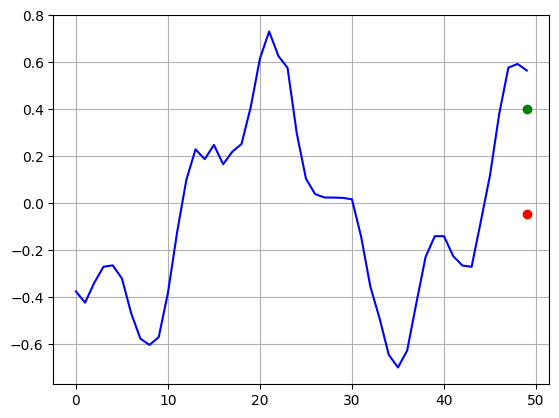

In [ ]:
# Funcion para mostrar las series y la prediccion
'''
Se podria indicar cual es le punto de la prediccion y cual el real en la leyenda
'''
def plot_series(series, y_true, y_pred):
    plt.plot(series, "b-")
    plt.plot([n_steps-1], [y_true], "go")
    plt.plot([n_steps-1], [y_pred], "ro")
    plt.grid(True)
    plt.show()

with torch.no_grad():
    sample_pred = model(X_valid[0:1]).item()
plot_series(X_valid[0,:,0], y_valid[0].item(), sample_pred)

In [ ]:
'''
Crea una nueva clase donde la red tiene mas layers. Repite el proceso anterior definiendo la pasada hacia adelante.
Define el optimizador y entrena el modelo. 
'''
class StackedRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn1 = nn.RNN(1, 20, batch_first=True)
        self.rnn2 = nn.RNN(20, 20, batch_first=True)
        self.rnn3 = nn.RNN(20, 1, batch_first=True)

    def forward(self, x):
        out1, _ = self.rnn1(x)
        out2, _ = self.rnn2(out1)
        _, h3 = self.rnn3(out2)
        return h3.squeeze(0) 

model = StackedRNN()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
train(model, X_train, y_train, X_valid, y_valid)

Epoch 1, loss=0.87199, val=0.76874
Epoch 2, loss=0.78010, val=0.66519
Epoch 3, loss=0.67488, val=0.55221
Epoch 4, loss=0.56008, val=0.43561
Epoch 5, loss=0.44153, val=0.32327
Epoch 6, loss=0.32716, val=0.22494
Epoch 7, loss=0.22670, val=0.15052
Epoch 8, loss=0.15010, val=0.10751
Epoch 9, loss=0.10487, val=0.09769
Epoch 10, loss=0.09287, val=0.11437
Epoch 11, loss=0.10760, val=0.14359
Epoch 12, loss=0.13525, val=0.17069
Epoch 13, loss=0.16133, val=0.18695
Epoch 14, loss=0.17709, val=0.19011
Epoch 15, loss=0.18023, val=0.18180
Epoch 16, loss=0.17229, val=0.16534
Epoch 17, loss=0.15647, val=0.14450
Epoch 18, loss=0.13646, val=0.12288
Epoch 19, loss=0.11576, val=0.10344
Epoch 20, loss=0.09729, val=0.08823


In [ ]:
# Muestra las perdidas del test
with torch.no_grad():
    test_loss = criterion(model(X_test), y_test)
print("Test Loss:", test_loss.item())

Test Loss: 0.08205952495336533


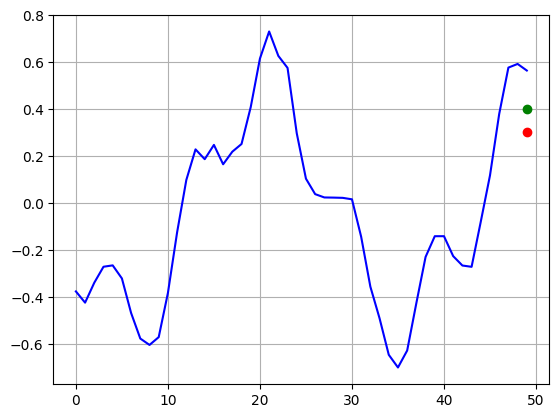

In [ ]:
# Muestra la serie el siguiente valor y la predicción 
with torch.no_grad():
    sample_pred = model(X_valid[0:1]).item()
plot_series(X_valid[0,:,0], y_valid[0].item(), sample_pred)